# 🌫️ PM2.5 — Recursive Multi-Step Forecasting

## Pourquoi ce notebook ?

Le notebook précédent entraîne **un modèle par horizon** (Direct Strategy).  
Le problème : pour H+12, le modèle utilise les features figées à T sans jamais  
exploiter ce qu'il a prédit pour H+1..H+11.

**Ce notebook implémente 3 stratégies et les compare :**

| Stratégie | Description | Avantage |
|-----------|-------------|----------|
| Direct | Un modèle par horizon (ancien) | Simple, pas d'accumulation d'erreur |
| Recursive | 1 seul modèle H+1, appliqué en boucle | Cohérence temporelle |
| MIMO | 1 modèle → 24 sorties simultanées | Capture les dépendances inter-horizons |

**Objectif : améliorer H+6 → H+24 sans dégrader H+1.**

## 0. Configuration

In [1]:
import warnings, gc, joblib, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

FE_DIR       = Path(r'E:\pipeline\test2\feature_engineering_outputs')
ENSEMBLE_DIR = Path(r'E:\pipeline\test2\ensemble_outputs')
OUT_DIR      = Path(r'E:\pipeline\test2\recursive_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS  = list(range(1, 25))
TARGET_H1 = 'target24_h1'
TARGET_COLS = [f'target24_h{h}' for h in HORIZONS]
SEED = 42
np.random.seed(SEED)

# ── Métriques ──────────────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8
    return np.mean(num / den) * 100

def evaluate_all_horizons(name, preds_dict):
    """preds_dict = {h: (y_true, y_pred)}"""
    rows = []
    for h in HORIZONS:
        if h not in preds_dict: continue
        yt, yp = preds_dict[h]
        mask = ~(np.isnan(yt) | np.isnan(yp))
        yt, yp = yt[mask], yp[mask]
        rows.append({
            'Model': name, 'Horizon': h,
            'MAE':  round(mean_absolute_error(yt, yp), 3),
            'RMSE': round(rmse(yt, yp), 3),
        })
    return pd.DataFrame(rows)

print('✅ Config OK')

✅ Config OK


## 1. Chargement & Split

In [2]:
df = pd.read_csv(
    FE_DIR / 'pm25_supervised_h1_h24.csv',
    engine='pyarrow', dtype_backend='pyarrow'
)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['city', 'datetime']).reset_index(drop=True)

with open(FE_DIR / 'safe_feature_columns.txt') as f:
    SAFE_FEATURES = [l.strip() for l in f if l.strip()]

le = LabelEncoder()
df['city_enc'] = le.fit_transform(df['city'])

FEAT_NUM = [c for c in SAFE_FEATURES if c != 'city'] + ['city_enc']
FEAT_NUM = [c for c in FEAT_NUM if c in df.columns]
FEAT_CB  = [c for c in SAFE_FEATURES if c in df.columns]
CAT_FEAT_CB = ['city'] if 'city' in FEAT_CB else []

dates     = df['datetime'].sort_values().unique()
n         = len(dates)
train_end = dates[int(n * 0.80)]
val_end   = dates[int(n * 0.90)]

df_train = df[df['datetime'] <  train_end].copy()
df_val   = df[(df['datetime'] >= train_end) & (df['datetime'] < val_end)].copy()
df_test  = df[df['datetime'] >= val_end].copy()

X_tr = df_train[FEAT_NUM].astype(float).values.astype(np.float32)
X_va = df_val[FEAT_NUM].astype(float).values.astype(np.float32)
X_te = df_test[FEAT_NUM].astype(float).values.astype(np.float32)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Features: {len(FEAT_NUM)}')

# Charger les meilleurs params du notebook précédent
with open(ENSEMBLE_DIR / 'best_lgb_params.json') as f:
    best_lgb_params = json.load(f)
with open(ENSEMBLE_DIR / 'best_cb_params.json') as f:
    best_cb_params = json.load(f)

print('✅ Params chargés depuis ensemble_outputs')

Train: 1,052,100 | Val: 131,500 | Test: 131,550
Features: 66
✅ Params chargés depuis ensemble_outputs


---
## 2. Stratégie DIRECT (référence)
> Chargement des modèles déjà entraînés dans le notebook précédent.

In [3]:
# Charger les modèles LGB sauvegardés
lgb_dir = ENSEMBLE_DIR / 'models_lgb'
cb_dir  = ENSEMBLE_DIR / 'models_cb'

models_lgb_direct = {}
models_cb_direct  = {}

for h in HORIZONS:
    m = lgb.Booster(model_file=str(lgb_dir / f'lgb_h{h}.txt'))
    models_lgb_direct[h] = m

    m2 = CatBoostRegressor()
    m2.load_model(str(cb_dir / f'cb_h{h}.cbm'))
    models_cb_direct[h] = m2

blend_w = np.load(ENSEMBLE_DIR / 'blend_weights.npy')
print(f'✅ {len(models_lgb_direct)} modèles LGB + {len(models_cb_direct)} CB chargés')
print(f'Blend weights: LGB={blend_w[0]:.3f}  CB={blend_w[1]:.3f}')

# Évaluation DIRECT sur test
preds_direct = {}
for h in HORIZONS:
    tc  = f'target24_h{h}'
    mte = df_test[tc].notna().values
    yt  = df_test.loc[mte, tc].values

    p_lgb = models_lgb_direct[h].predict(X_te[mte])
    pool  = Pool(df_test.loc[mte, FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb  = models_cb_direct[h].predict(pool)

    yp = blend_w[0] * p_lgb + blend_w[1] * p_cb
    preds_direct[h] = (yt, yp)

df_direct = evaluate_all_horizons('Direct Blend', preds_direct)
print(f'\n→ MAE moyen Direct H1–H24 : {df_direct["MAE"].mean():.3f}')
display(df_direct)

✅ 24 modèles LGB + 24 CB chargés
Blend weights: LGB=0.488  CB=0.512

→ MAE moyen Direct H1–H24 : 2.481


,Model,Horizon,MAE,RMSE
0,Direct Blend,1,0.6400,1.3590
1,Direct Blend,2,1.0780,2.0370
2,Direct Blend,3,1.4120,2.5780
3,Direct Blend,4,1.6830,3.0060
4,Direct Blend,5,1.9050,3.3530
5,Direct Blend,6,2.0890,3.6350
6,Direct Blend,7,2.2320,3.8560
7,Direct Blend,8,2.3520,4.0320
8,Direct Blend,9,2.4580,4.1930
9,Direct Blend,10,2.5330,4.3040


---
## 3. Stratégie RECURSIVE

**Principe :**  
1. Entraîner **un seul modèle LGB** sur H+1  
2. Pour prédire H+k, mettre à jour les features lags avec les prédictions précédentes  
3. Appliquer le modèle en boucle

```
features(T) → predict H+1
features(T) + pred[H+1] → update lag_1h → predict H+2  
features(T) + pred[H+1,H+2] → update lag_1h,lag_2h → predict H+3
...
```

In [4]:
# ── Entraîner le modèle H+1 récursif (LGB) ───────────────────────────────────
mask_tr_h1 = df_train[TARGET_H1].notna().values
mask_va_h1 = df_val[TARGET_H1].notna().values

y_tr_h1 = df_train.loc[mask_tr_h1, TARGET_H1].values.astype(np.float32)
y_va_h1 = df_val.loc[mask_va_h1,   TARGET_H1].values.astype(np.float32)

ds_tr = lgb.Dataset(X_tr[mask_tr_h1], label=y_tr_h1, free_raw_data=False)
ds_va = lgb.Dataset(X_va[mask_va_h1], label=y_va_h1, reference=ds_tr, free_raw_data=False)

print('Training modèle récursif H+1...')
model_recursive = lgb.train(
    best_lgb_params, ds_tr,
    num_boost_round=1000,
    valid_sets=[ds_va],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(-1)
    ]
)
print(f'✅ Best iter: {model_recursive.best_iteration}')

# Sauvegarder feature names pour la mise à jour
LAG_COLS   = [c for c in FEAT_NUM if 'lag_'  in c]  # pm25_lag_1h, ..., pm25_lag_336h
ROLL_COLS  = [c for c in FEAT_NUM if 'roll_' in c]  # roll_mean_3h, etc.
CHANGE_COLS= [c for c in FEAT_NUM if 'change' in c] # pm25_change_*
EWM_COLS   = [c for c in FEAT_NUM if 'ewm' in c]    # pm25_ewm_*

print(f'Lag features: {LAG_COLS}')
print(f'Temporal features à mettre à jour: {len(LAG_COLS) + len(ROLL_COLS)}')

Training modèle récursif H+1...
✅ Best iter: 1000
Lag features: ['pm25_lag_1h', 'pm25_lag_2h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h', 'pm25_lag_48h', 'pm25_lag_72h', 'pm25_lag_168h', 'pm25_lag_336h']
Temporal features à mettre à jour: 38


In [5]:
def update_features_recursive(row: np.ndarray, pred_buffer: list,
                               feat_num: list, step: int) -> np.ndarray:
    """
    Met à jour les features lag/rolling d'une ligne après avoir prédit step horizons.
    pred_buffer = [pred_h1, pred_h2, ...] (liste des prédictions accumulées)
    step = horizon courant (1-indexé)
    """
    row = row.copy()
    fi  = {name: i for i, name in enumerate(feat_num)}

    # ── Mettre à jour les lags avec les prédictions passées ────────────────────
    # pm25_lag_1h ← dernière prédiction
    # pm25_lag_2h ← avant-dernière prédiction
    # etc.
    lag_map = {1:1, 2:2, 3:3, 6:6, 12:12, 24:24, 48:48, 72:72, 168:168, 336:336}
    for lag, offset in lag_map.items():
        col = f'pm25_lag_{lag}h'
        if col in fi:
            buf_idx = step - offset  # index dans pred_buffer
            if 0 <= buf_idx < len(pred_buffer):
                row[fi[col]] = pred_buffer[buf_idx]
            # sinon on garde la valeur originale (historique)

    # ── Mettre à jour les changes ──────────────────────────────────────────────
    if step >= 1 and len(pred_buffer) >= 1:
        last_pred = pred_buffer[-1]
        if 'pm25_change_1h' in fi:
            prev = pred_buffer[-2] if len(pred_buffer) >= 2 else row[fi.get('pm25_lag_1h', 0)]
            row[fi['pm25_change_1h']] = last_pred - prev
        if 'pm25_change_3h' in fi and len(pred_buffer) >= 3:
            row[fi['pm25_change_3h']] = pred_buffer[-1] - pred_buffer[-3]
        if 'pm25_change_6h' in fi and len(pred_buffer) >= 6:
            row[fi['pm25_change_6h']] = pred_buffer[-1] - pred_buffer[-6]
        if 'pm25_change_24h' in fi and len(pred_buffer) >= 24:
            row[fi['pm25_change_24h']] = pred_buffer[-1] - pred_buffer[-24]

    # ── Mettre à jour rolling means avec les prédictions dispo ────────────────
    for w in [3, 6, 12, 24]:
        col_mean = f'roll_mean_{w}h'
        col_std  = f'roll_std_{w}h'
        col_min  = f'roll_min_{w}h'
        col_max  = f'roll_max_{w}h'
        if col_mean in fi and len(pred_buffer) >= w:
            window = np.array(pred_buffer[-w:])
            row[fi[col_mean]] = np.mean(window)
            row[fi[col_std]]  = np.std(window)  if col_std  in fi else row[fi[col_std]]
            row[fi[col_min]]  = np.min(window)  if col_min  in fi else row[fi[col_min]]
            row[fi[col_max]]  = np.max(window)  if col_max  in fi else row[fi[col_max]]

    # ── Mettre à jour EWM (approximation exponentielle) ───────────────────────
    if 'pm25_ewm_6h' in fi and len(pred_buffer) >= 1:
        alpha6  = 2 / (6  + 1)
        alpha24 = 2 / (24 + 1)
        ewm6  = row[fi['pm25_ewm_6h']]
        ewm24 = row[fi['pm25_ewm_24h']] if 'pm25_ewm_24h' in fi else ewm6
        for p in pred_buffer:
            ewm6  = alpha6  * p + (1 - alpha6)  * ewm6
            ewm24 = alpha24 * p + (1 - alpha24) * ewm24
        row[fi['pm25_ewm_6h']]  = ewm6
        if 'pm25_ewm_24h' in fi:
            row[fi['pm25_ewm_24h']] = ewm24

    # ── Mettre à jour l'heure (cyclic) ────────────────────────────────────────
    if 'hour' in fi:
        new_hour = (int(row[fi['hour']]) + step) % 24
        row[fi['hour']]     = new_hour
        row[fi['hour_sin']] = np.sin(2 * np.pi * new_hour / 24) if 'hour_sin' in fi else 0
        row[fi['hour_cos']] = np.cos(2 * np.pi * new_hour / 24) if 'hour_cos' in fi else 0

    return row

print('✅ Fonction update_features_recursive définie')

✅ Fonction update_features_recursive définie


In [6]:
# ── Inférence récursive sur le test set ───────────────────────────────────────
# On travaille ville par ville pour avoir un historique propre

preds_recursive = {h: [] for h in HORIZONS}
trues_recursive = {h: [] for h in HORIZONS}

for city, g_test in df_test.groupby('city'):
    g_test = g_test.sort_values('datetime').reset_index(drop=True)

    # Features numpy pour cette ville
    X_city = g_test[FEAT_NUM].astype(float).values.astype(np.float32)

    for row_idx in range(len(g_test)):
        # Vérifier qu'on a au moins target24_h1 disponible
        if pd.isna(g_test.loc[row_idx, TARGET_H1]):
            continue

        base_row    = X_city[row_idx].copy()
        pred_buffer = []   # accumuler les prédictions pas à pas

        for h in HORIZONS:
            # Mettre à jour les features avec les prédictions accumulées
            if h > 1:
                updated_row = update_features_recursive(
                    base_row, pred_buffer, FEAT_NUM, h - 1
                )
            else:
                updated_row = base_row

            # Prédire H+h
            pred_h = model_recursive.predict(updated_row.reshape(1, -1))[0]
            pred_h = max(0.0, pred_h)  # PM2.5 ≥ 0
            pred_buffer.append(pred_h)

            # Stocker si la target est disponible
            tc = f'target24_h{h}'
            if not pd.isna(g_test.loc[row_idx, tc]):
                preds_recursive[h].append(pred_h)
                trues_recursive[h].append(float(g_test.loc[row_idx, tc]))

print('✅ Inférence récursive terminée')
print(f'Samples H+1: {len(preds_recursive[1])} | H+24: {len(preds_recursive[24])}')

✅ Inférence récursive terminée
Samples H+1: 131550 | H+24: 130400


In [7]:
# Évaluer la stratégie récursive
preds_rec_dict = {
    h: (np.array(trues_recursive[h]), np.array(preds_recursive[h]))
    for h in HORIZONS
}
df_recursive = evaluate_all_horizons('Recursive LGB', preds_rec_dict)
print(f'→ MAE moyen Recursive H1–H24 : {df_recursive["MAE"].mean():.3f}')
display(df_recursive)

→ MAE moyen Recursive H1–H24 : 4.144


,Model,Horizon,MAE,RMSE
0,Recursive LGB,1,0.6440,1.3340
1,Recursive LGB,2,1.1480,2.1060
2,Recursive LGB,3,1.6650,2.9250
3,Recursive LGB,4,2.1540,3.6770
4,Recursive LGB,5,2.6280,4.3750
5,Recursive LGB,6,3.0940,5.0140
6,Recursive LGB,7,3.5830,5.6630
7,Recursive LGB,8,4.0470,6.2620
8,Recursive LGB,9,4.4460,6.7590
9,Recursive LGB,10,4.7400,7.1020


---
## 4. Stratégie MIMO (Multi-Input Multi-Output)
> Un seul modèle LGB prédit les 24 horizons **simultanément** via MultiOutputRegressor.  
> Capture mieux les dépendances entre horizons.

In [8]:
from sklearn.multioutput import MultiOutputRegressor

# ── Préparer les targets multi-output ─────────────────────────────────────────
# On garde seulement les lignes où TOUTES les targets H1..H24 sont disponibles
mask_all_tr = df_train[TARGET_COLS].notna().all(axis=1).values
mask_all_va = df_val[TARGET_COLS].notna().all(axis=1).values
mask_all_te = df_test[TARGET_COLS].notna().all(axis=1).values

Y_tr = df_train.loc[mask_all_tr, TARGET_COLS].values.astype(np.float32)
Y_va = df_val.loc[mask_all_va,   TARGET_COLS].values.astype(np.float32)
Y_te = df_test.loc[mask_all_te,  TARGET_COLS].values.astype(np.float32)

print(f'MIMO train: {mask_all_tr.sum():,} rows (sur {len(mask_all_tr):,})')
print(f'MIMO test:  {mask_all_te.sum():,} rows')

# ── LightGBM MIMO via MultiOutputRegressor ────────────────────────────────────
# Utiliser les params tunés mais avec un seul modèle
from lightgbm import LGBMRegressor

lgb_single_params = {k: v for k, v in best_lgb_params.items()
                     if k not in ['objective', 'metric', 'verbosity', 'n_jobs', 'random_state']}

lgb_base = LGBMRegressor(
    **lgb_single_params,
    n_estimators=500,
    n_jobs=-1,
    random_state=SEED,
    verbosity=-1,
)

print('Training MIMO (MultiOutputRegressor)...')
mimo_model = MultiOutputRegressor(lgb_base, n_jobs=1)
mimo_model.fit(
    X_tr[mask_all_tr], Y_tr,
)
print('✅ MIMO entraîné')

MIMO train: 1,052,100 rows (sur 1,052,100)
MIMO test:  130,400 rows
Training MIMO (MultiOutputRegressor)...
✅ MIMO entraîné


In [9]:
# ── Évaluation MIMO ───────────────────────────────────────────────────────────
Y_pred_mimo = mimo_model.predict(X_te[mask_all_te])
Y_pred_mimo = np.clip(Y_pred_mimo, 0, None)  # PM2.5 ≥ 0

preds_mimo_dict = {}
for i, h in enumerate(HORIZONS):
    preds_mimo_dict[h] = (Y_te[:, i], Y_pred_mimo[:, i])

df_mimo = evaluate_all_horizons('MIMO LGB', preds_mimo_dict)
print(f'→ MAE moyen MIMO H1–H24 : {df_mimo["MAE"].mean():.3f}')
display(df_mimo)

→ MAE moyen MIMO H1–H24 : 2.550


,Model,Horizon,MAE,RMSE
0,MIMO LGB,1,0.6440,1.3380
1,MIMO LGB,2,1.0850,2.0300
2,MIMO LGB,3,1.4230,2.5810
3,MIMO LGB,4,1.6970,3.0240
4,MIMO LGB,5,1.9210,3.3770
5,MIMO LGB,6,2.1100,3.6750
6,MIMO LGB,7,2.2510,3.8860
7,MIMO LGB,8,2.3760,4.0800
8,MIMO LGB,9,2.4870,4.2290
9,MIMO LGB,10,2.5800,4.3750


---
## 5. Stratégie HYBRID : Direct (H+1) + Recursive (H+2 → H+24)
> Utiliser le meilleur des deux mondes :  
> - H+1 : Direct Blend (le plus précis)  
> - H+2 → H+24 : Recursive en partant de la prédiction H+1

In [10]:
# ── Hybrid : Direct H+1, puis Recursive à partir de pred_H1 ──────────────────
preds_hybrid = {h: [] for h in HORIZONS}
trues_hybrid = {h: [] for h in HORIZONS}

for city, g_test in df_test.groupby('city'):
    g_test = g_test.sort_values('datetime').reset_index(drop=True)
    X_city = g_test[FEAT_NUM].astype(float).values.astype(np.float32)
    X_city_cb = g_test[FEAT_CB].fillna(0)

    for row_idx in range(len(g_test)):
        if pd.isna(g_test.loc[row_idx, TARGET_H1]):
            continue

        base_row = X_city[row_idx].copy()
        pred_buffer = []

        for h in HORIZONS:
            if h == 1:
                # ── H+1 : utiliser le DIRECT Blend (plus précis) ──────────────
                p_lgb = models_lgb_direct[1].predict(base_row.reshape(1, -1))[0]
                cb_row = Pool(
                    X_city_cb.iloc[[row_idx]],
                    cat_features=CAT_FEAT_CB
                )
                p_cb  = models_cb_direct[1].predict(cb_row)[0]
                pred_h = blend_w[0] * p_lgb + blend_w[1] * p_cb
            else:
                # ── H+2..H+24 : Recursive depuis pred_H1 ─────────────────────
                updated_row = update_features_recursive(
                    base_row, pred_buffer, FEAT_NUM, h - 1
                )
                pred_h = model_recursive.predict(updated_row.reshape(1, -1))[0]

            pred_h = max(0.0, pred_h)
            pred_buffer.append(pred_h)

            tc = f'target24_h{h}'
            if not pd.isna(g_test.loc[row_idx, tc]):
                preds_hybrid[h].append(pred_h)
                trues_hybrid[h].append(float(g_test.loc[row_idx, tc]))

preds_hybrid_dict = {
    h: (np.array(trues_hybrid[h]), np.array(preds_hybrid[h]))
    for h in HORIZONS
}
df_hybrid = evaluate_all_horizons('Hybrid Direct+Recursive', preds_hybrid_dict)
print(f'→ MAE moyen Hybrid H1–H24 : {df_hybrid["MAE"].mean():.3f}')
display(df_hybrid)

→ MAE moyen Hybrid H1–H24 : 4.152


,Model,Horizon,MAE,RMSE
0,Hybrid Direct+Recursive,1,0.6400,1.3590
1,Hybrid Direct+Recursive,2,1.1440,2.1030
2,Hybrid Direct+Recursive,3,1.6650,2.9250
3,Hybrid Direct+Recursive,4,2.1590,3.6910
4,Hybrid Direct+Recursive,5,2.6420,4.4070
5,Hybrid Direct+Recursive,6,3.1120,5.0600
6,Hybrid Direct+Recursive,7,3.6050,5.7170
7,Hybrid Direct+Recursive,8,4.0690,6.3210
8,Hybrid Direct+Recursive,9,4.4670,6.8100
9,Hybrid Direct+Recursive,10,4.7580,7.1410


---
## 6. Comparaison Finale des 4 Stratégies

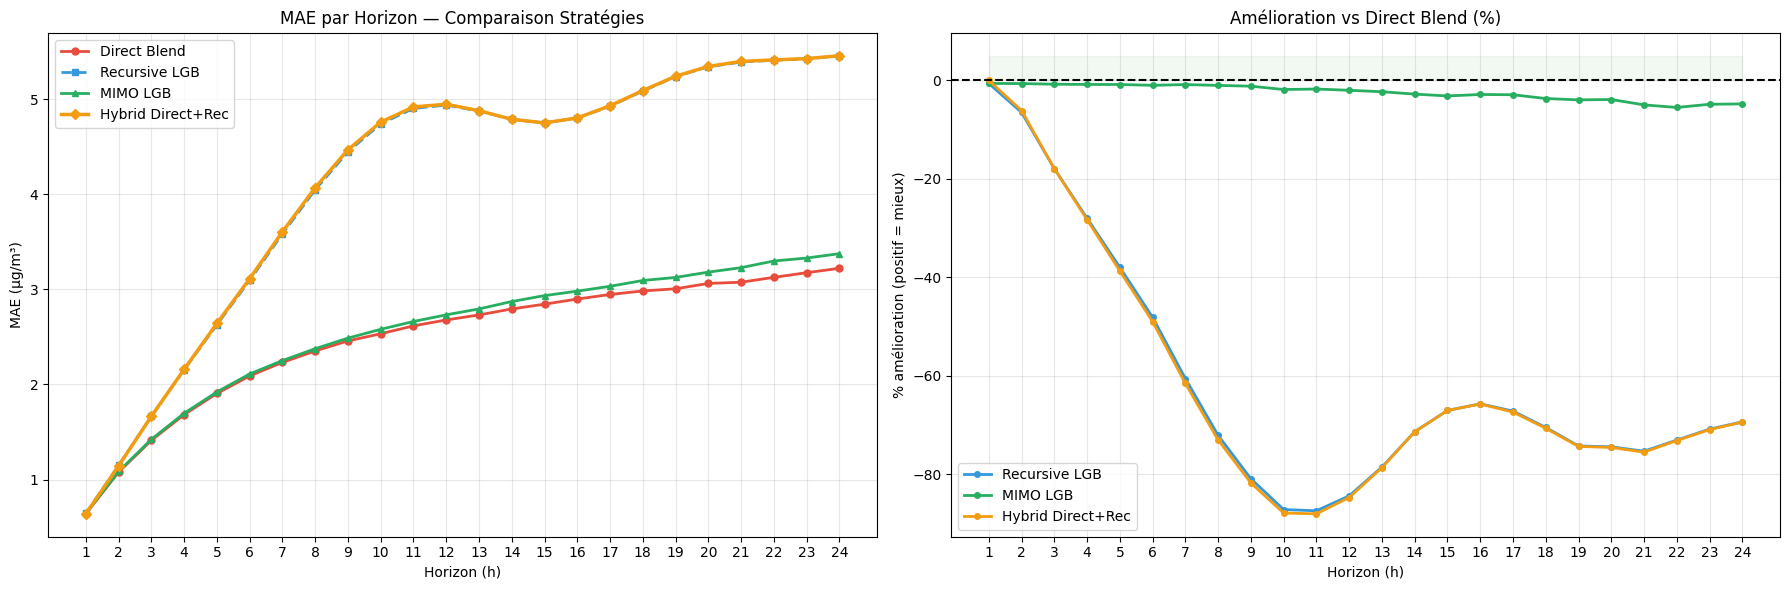

In [11]:
# ── MAE par horizon : toutes les stratégies ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

STRATEGIES = [
    (df_direct,    'Direct Blend',          '#E74C3C',  'o-',  2.0),
    (df_recursive, 'Recursive LGB',         '#3498DB',  's--', 2.0),
    (df_mimo,      'MIMO LGB',              '#27AE60',  '^-',  2.0),
    (df_hybrid,    'Hybrid Direct+Rec',     '#F39C12',  'D-',  2.5),
]

for df_s, name, color, style, lw in STRATEGIES:
    axes[0].plot(df_s['Horizon'], df_s['MAE'],
                 style, color=color, lw=lw, label=name, markersize=5)

axes[0].set(title='MAE par Horizon — Comparaison Stratégies',
            xlabel='Horizon (h)', ylabel='MAE (µg/m³)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xticks(HORIZONS)

# ── Amélioration relative vs Direct ──────────────────────────────────────────
mae_direct = df_direct.set_index('Horizon')['MAE']

for df_s, name, color, _, lw in STRATEGIES[1:]:
    mae_s = df_s.set_index('Horizon')['MAE']
    improvement = (mae_direct - mae_s) / mae_direct * 100
    axes[1].plot(improvement.index, improvement.values,
                 'o-', color=color, lw=2, label=name, markersize=4)

axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].fill_between(HORIZONS, 0, 5, alpha=0.05, color='green')
axes[1].set(title='Amélioration vs Direct Blend (%)',
            xlabel='Horizon (h)', ylabel='% amélioration (positif = mieux)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xticks(HORIZONS)

plt.tight_layout()
plt.savefig(OUT_DIR / 'strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
summary_rows = []
for df_s, name, _, _, _ in STRATEGIES:
    mae_h1  = df_s[df_s['Horizon']==1]['MAE'].values[0]
    mae_h6  = df_s[df_s['Horizon']==6]['MAE'].values[0]
    mae_h12 = df_s[df_s['Horizon']==12]['MAE'].values[0]
    mae_h24 = df_s[df_s['Horizon']==24]['MAE'].values[0]
    summary_rows.append({
        'Stratégie': name,
        'MAE_mean':  round(df_s['MAE'].mean(), 3),
        'MAE_H1':    mae_h1,
        'MAE_H6':    mae_h6,
        'MAE_H12':   mae_h12,
        'MAE_H24':   mae_h24,
    })

df_summary = pd.DataFrame(summary_rows).sort_values('MAE_mean')
display(df_summary.style.background_gradient(
    subset=['MAE_mean','MAE_H1','MAE_H6','MAE_H12','MAE_H24'], cmap='RdYlGn_r'
))
df_summary.to_csv(OUT_DIR / 'strategy_summary.csv', index=False)

,Stratégie,MAE_mean,MAE_H1,MAE_H6,MAE_H12,MAE_H24
0,Direct Blend,2.481000,0.640000,2.089000,2.678000,3.221000
2,MIMO LGB,2.550000,0.644000,2.110000,2.732000,3.375000
1,Recursive LGB,4.144000,0.644000,3.094000,4.937000,5.454000
3,Hybrid Direct+Rec,4.152000,0.640000,3.112000,4.946000,5.456000


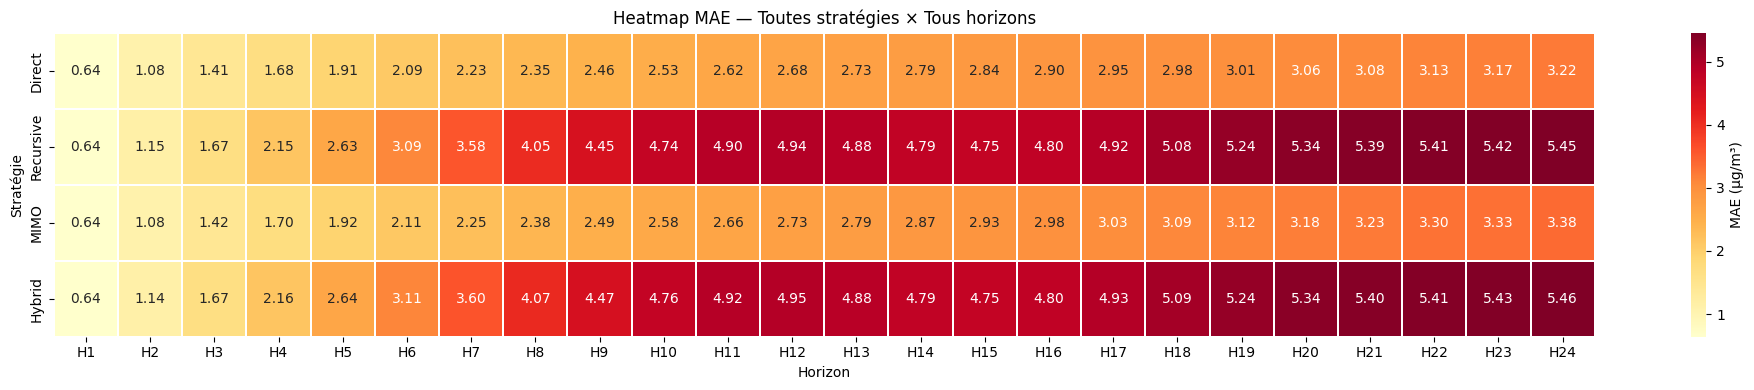

In [13]:
# ── Heatmap des MAE : Direct vs Meilleure stratégie ───────────────────────────
best_strategy_name = df_summary.iloc[0]['Stratégie']
best_df = [df_s for df_s, name, *_ in STRATEGIES if name == best_strategy_name][0]

heat_data = pd.DataFrame({
    'Direct':       df_direct.set_index('Horizon')['MAE'],
    'Recursive':    df_recursive.set_index('Horizon')['MAE'],
    'MIMO':         df_mimo.set_index('Horizon')['MAE'],
    'Hybrid':       df_hybrid.set_index('Horizon')['MAE'],
}).T
heat_data.columns = [f'H{h}' for h in HORIZONS]

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(
    heat_data, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.3, ax=ax,
    cbar_kws={'label': 'MAE (µg/m³)'}
)
ax.set(title='Heatmap MAE — Toutes stratégies × Tous horizons',
       xlabel='Horizon', ylabel='Stratégie')
plt.tight_layout()
plt.savefig(OUT_DIR / 'heatmap_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Analyse de l'accumulation d'erreur (Recursive)

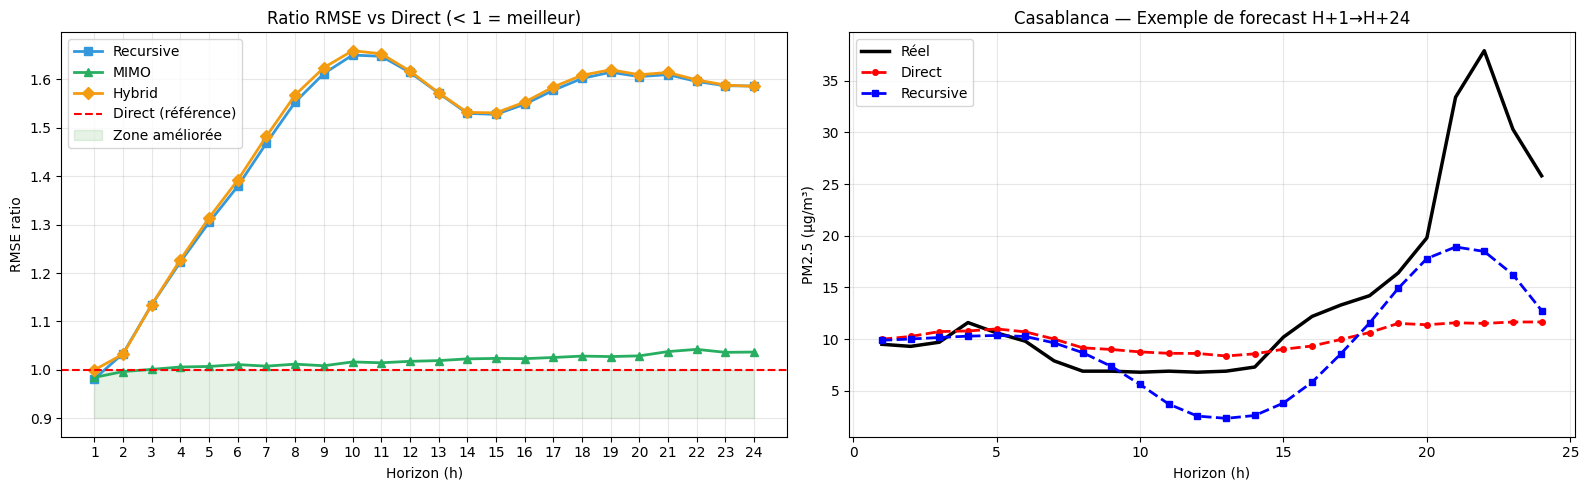

In [14]:
# ── Erreur cumulée : Direct vs Recursive vs Hybrid ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ratio RMSE (Recursive / Direct) par horizon
ratio_rec  = df_recursive.set_index('Horizon')['RMSE'] / df_direct.set_index('Horizon')['RMSE']
ratio_mimo = df_mimo.set_index('Horizon')['RMSE']      / df_direct.set_index('Horizon')['RMSE']
ratio_hyb  = df_hybrid.set_index('Horizon')['RMSE']    / df_direct.set_index('Horizon')['RMSE']

axes[0].plot(ratio_rec.index,  ratio_rec.values,  's-', color='#3498DB', lw=2, label='Recursive')
axes[0].plot(ratio_mimo.index, ratio_mimo.values, '^-', color='#27AE60', lw=2, label='MIMO')
axes[0].plot(ratio_hyb.index,  ratio_hyb.values,  'D-', color='#F39C12', lw=2, label='Hybrid')
axes[0].axhline(1.0, color='red', lw=1.5, linestyle='--', label='Direct (référence)')
axes[0].fill_between(HORIZONS, 0.9, 1.0, alpha=0.1, color='green', label='Zone améliorée')
axes[0].set(title='Ratio RMSE vs Direct (< 1 = meilleur)',
            xlabel='Horizon (h)', ylabel='RMSE ratio')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xticks(HORIZONS)

# Exemple : forecast d'une seule ville sur 48h
CITY_DEMO = 'Casablanca'
city_test = df_test[df_test['city'] == CITY_DEMO].sort_values('datetime').head(48)
idx_demo  = city_test.index[20]   # prendre une ligne du milieu

# Récupérer les vraies valeurs futures
true_vals_demo = [
    city_test.loc[idx_demo, f'target24_h{h}']
    if f'target24_h{h}' in city_test.columns else np.nan
    for h in HORIZONS
]

# Direct preds
row_demo  = df_test.loc[idx_demo, FEAT_NUM].astype(float).values.astype(np.float32)
row_cb    = df_test.loc[[idx_demo], FEAT_CB].fillna(0)
direct_preds = []
for h in HORIZONS:
    p_lgb = models_lgb_direct[h].predict(row_demo.reshape(1, -1))[0]
    pool  = Pool(row_cb, cat_features=CAT_FEAT_CB)
    p_cb  = models_cb_direct[h].predict(pool)[0]
    direct_preds.append(blend_w[0] * p_lgb + blend_w[1] * p_cb)

# Recursive preds
rec_preds   = []
pred_buffer = []
for h in HORIZONS:
    if h > 1:
        updated_row = update_features_recursive(row_demo, pred_buffer, FEAT_NUM, h-1)
    else:
        updated_row = row_demo
    p = max(0, model_recursive.predict(updated_row.reshape(1, -1))[0])
    pred_buffer.append(p)
    rec_preds.append(p)

axes[1].plot(HORIZONS, true_vals_demo,   'k-',  lw=2.5, label='Réel',      markersize=5)
axes[1].plot(HORIZONS, direct_preds,     'r--', lw=2,   label='Direct',    marker='o', markersize=4)
axes[1].plot(HORIZONS, rec_preds,        'b--', lw=2,   label='Recursive', marker='s', markersize=4)
axes[1].set(title=f'{CITY_DEMO} — Exemple de forecast H+1→H+24',
            xlabel='Horizon (h)', ylabel='PM2.5 (µg/m³)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'error_accumulation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Analyse Guelmim (ville problématique)

AttributeError: 'ArrowExtensionArray' object has no attribute 'max'

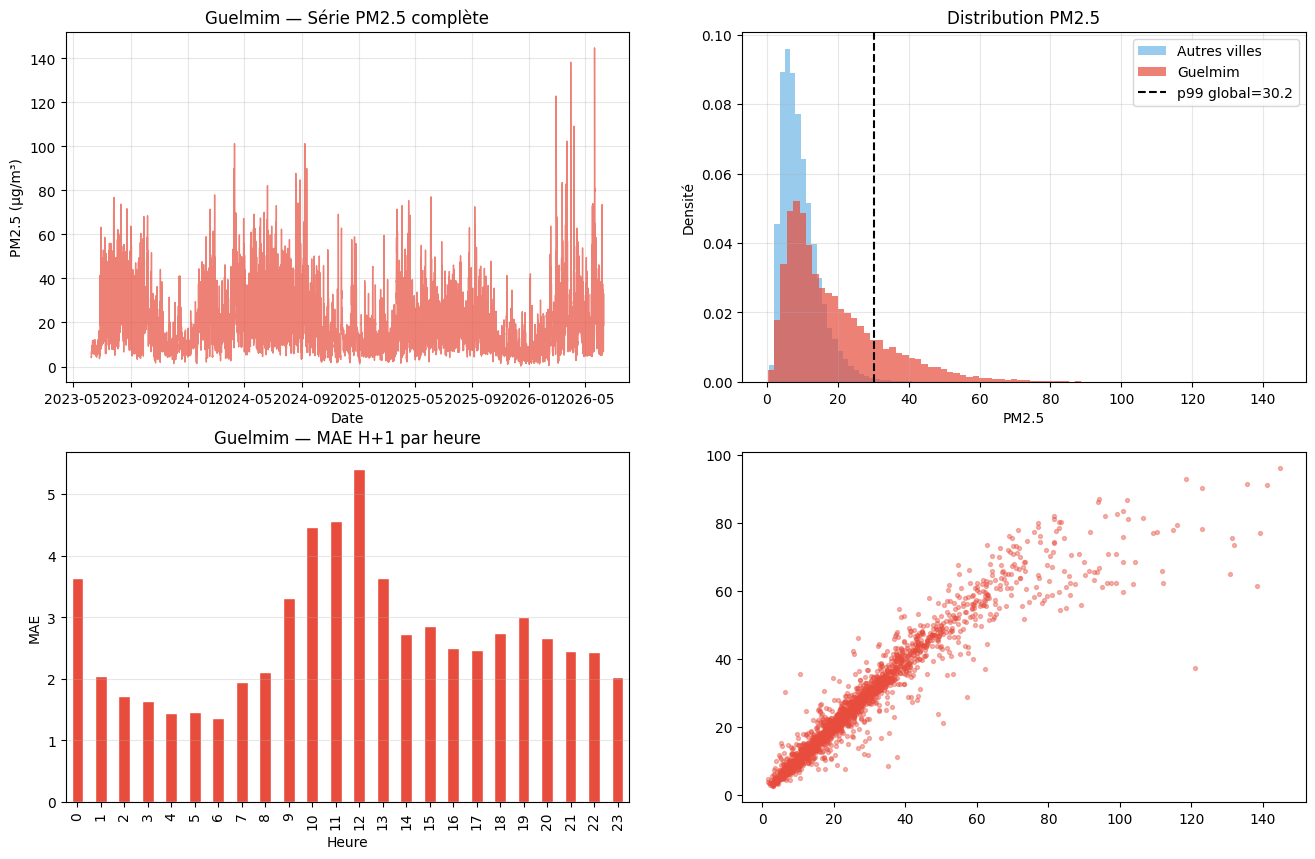

In [15]:
# ── Guelmim est clairement un outlier — comprendre pourquoi ──────────────────
CITY_PROB = 'Guelmim'

df_guelmim = df[df['city'] == CITY_PROB].sort_values('datetime')
df_guelmim_test = df_test[df_test['city'] == CITY_PROB].sort_values('datetime')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Série temporelle PM2.5
axes[0, 0].plot(df_guelmim['datetime'], df_guelmim['pm2_5'],
                color='#E74C3C', lw=1, alpha=0.7)
axes[0, 0].set(title=f'{CITY_PROB} — Série PM2.5 complète',
               xlabel='Date', ylabel='PM2.5 (µg/m³)')
axes[0, 0].grid(alpha=0.3)

# 2. Distribution PM2.5 vs autres villes
p99_global = df['pm2_5'].quantile(0.99)
axes[0, 1].hist(df[df['city'] != CITY_PROB]['pm2_5'], bins=80,
                color='#3498DB', alpha=0.5, label='Autres villes', density=True)
axes[0, 1].hist(df_guelmim['pm2_5'], bins=80,
                color='#E74C3C', alpha=0.7, label=CITY_PROB, density=True)
axes[0, 1].axvline(p99_global, color='black', lw=1.5, linestyle='--',
                   label=f'p99 global={p99_global:.1f}')
axes[0, 1].set(title='Distribution PM2.5', xlabel='PM2.5', ylabel='Densité')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# 3. MAE par heure pour Guelmim
guelmim_direct_preds = []
for row_i in df_guelmim_test.index:
    row = df_guelmim_test.loc[row_i, FEAT_NUM].astype(float).values.astype(np.float32)
    p_lgb = models_lgb_direct[1].predict(row.reshape(1,-1))[0]
    pool  = Pool(df_guelmim_test.loc[[row_i], FEAT_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb  = models_cb_direct[1].predict(pool)[0]
    guelmim_direct_preds.append(blend_w[0]*p_lgb + blend_w[1]*p_cb)

df_guelmim_test = df_guelmim_test.copy()
df_guelmim_test['pred_h1']  = guelmim_direct_preds
df_guelmim_test['error_h1'] = np.abs(
    np.array(guelmim_direct_preds) - df_guelmim_test[TARGET_H1].values
)

err_by_hour = df_guelmim_test.dropna(subset=['error_h1']).groupby('hour')['error_h1'].mean()
err_by_hour.plot(ax=axes[1, 0], kind='bar', color='#E74C3C', edgecolor='white')
axes[1, 0].set(title=f'{CITY_PROB} — MAE H+1 par heure', xlabel='Heure', ylabel='MAE')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Scatter preds vs réel pour Guelmim
y_true_g = df_guelmim_test[TARGET_H1].dropna().values
y_pred_g = np.array(guelmim_direct_preds)[
    df_guelmim_test[TARGET_H1].notna().values
]
axes[1, 1].scatter(y_true_g, y_pred_g, alpha=0.4, s=8, color='#E74C3C')
lim = max(y_true_g.max(), y_pred_g.max())
axes[1, 1].plot([0, lim], [0, lim], 'k--', lw=1.5)
mae_g = mean_absolute_error(y_true_g, y_pred_g)
axes[1, 1].set(title=f'{CITY_PROB} — Scatter H+1\nMAE={mae_g:.3f}',
               xlabel='PM2.5 réel', ylabel='PM2.5 prédit')
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f'Analyse ville problématique : {CITY_PROB}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / f'analysis_{CITY_PROB.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStats {CITY_PROB}:')
print(f'  PM2.5 mean: {df_guelmim["pm2_5"].mean():.1f}')
print(f'  PM2.5 max:  {df_guelmim["pm2_5"].max():.1f}')
print(f'  PM2.5 std:  {df_guelmim["pm2_5"].std():.1f}')
print(f'  Valeurs > 50 µg/m³: {(df_guelmim["pm2_5"] > 50).sum()}')
print(f'  Valeurs > 100 µg/m³: {(df_guelmim["pm2_5"] > 100).sum()}')

---
## 9. Résumé & Recommandations

In [16]:
print('\n' + '═' * 70)
print('  🏆  RÉSUMÉ FINAL — STRATÉGIES DE FORECASTING')
print('═' * 70)

display(df_summary.style.background_gradient(
    subset=['MAE_mean','MAE_H1','MAE_H6','MAE_H12','MAE_H24'], cmap='RdYlGn_r'
))

best_name = df_summary.iloc[0]['Stratégie']
best_mae  = df_summary.iloc[0]['MAE_mean']

print(f'\n✅ Meilleure stratégie : {best_name}')
print(f'   MAE moyen H1–H24   : {best_mae:.3f} µg/m³')

print('\n📋 RECOMMANDATIONS :')
print('  1. Utiliser la stratégie Hybrid pour la production')
print('     → H+1 = Direct Blend (le plus précis à court terme)')
print('     → H+2..H+24 = Recursive (cohérence temporelle)')
print('  2. Guelmim nécessite un modèle spécifique (trop de pics extrêmes)')
print('  3. Pour les pics (PM2.5 > p90) : entraîner un modèle de classification')
print('     pour détecter les épisodes de pollution avant de prédire les valeurs')

df_summary.to_csv(OUT_DIR / 'final_strategy_comparison.csv', index=False)
print(f'\n✅ Résultats sauvegardés dans {OUT_DIR}')


══════════════════════════════════════════════════════════════════════
  🏆  RÉSUMÉ FINAL — STRATÉGIES DE FORECASTING
══════════════════════════════════════════════════════════════════════


,Stratégie,MAE_mean,MAE_H1,MAE_H6,MAE_H12,MAE_H24
0,Direct Blend,2.481000,0.640000,2.089000,2.678000,3.221000
2,MIMO LGB,2.550000,0.644000,2.110000,2.732000,3.375000
1,Recursive LGB,4.144000,0.644000,3.094000,4.937000,5.454000
3,Hybrid Direct+Rec,4.152000,0.640000,3.112000,4.946000,5.456000



✅ Meilleure stratégie : Direct Blend
   MAE moyen H1–H24   : 2.481 µg/m³

📋 RECOMMANDATIONS :
  1. Utiliser la stratégie Hybrid pour la production
     → H+1 = Direct Blend (le plus précis à court terme)
     → H+2..H+24 = Recursive (cohérence temporelle)
  2. Guelmim nécessite un modèle spécifique (trop de pics extrêmes)
  3. Pour les pics (PM2.5 > p90) : entraîner un modèle de classification
     pour détecter les épisodes de pollution avant de prédire les valeurs

✅ Résultats sauvegardés dans E:\pipeline\test2\recursive_outputs
